HEART DISEASE PREDICTION


In [67]:
from IPython.display import Image, display

display(Image(url="https://raw.githubusercontent.com/FarzadNekouee/Heart_Disease_Prediction/master/image.jpg"))



Machine learning project 
Heart Disease Prediction

IN this projec I got the dataset from the kaggle and the dataset contains 15000 rows and 15 columns(features) the feature including Age,Sex, chest pain type,Blood Pressure, Cholesterol,Maximiu heart Rate and more.our goal is develop a predictive model capable of accurately identifying individuals with heart disease.


**OBJECTIVES**
.**Explore** the dataset:Uncover patterns, distributions, and relationships within the data.
**.Exploratory data analysis**: it focus on the detail of the data that include visualization
.**Preprocessing Steps**:
                    Remove irrelevant features
                    Address missing values
                    Treat outliers
                    Encode categorical variables
**model building**:
.implment supervaised machine learning models including LogisticRegression,KNN and Random Forest.and select the model which is best in accurcy,prediction,f1_score based on the result of comparession table
.**Evaluate and Compare Model Performance:** Utilize precision, recall, and F1-score to gauge models' effectiveness.


In [68]:
##  1 import important python  libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [69]:
## load dataset

In [70]:
##  data overview
## read dataset
data=pd.read_csv('heart_raw.csv')
data.head(10)

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58.0,Male,asymptomatic,152.0,239.0,0,normal,158.0,Yes,3.6,2,2,reversable defect,Presence
1,1,52.0,Male,typical angina,125.0,325.0,0,left ventricular hypertrophy,171.0,No,0.0,1,0,normal,Absence
2,2,56.0,Female,atypical angina,160.0,188.0,0,left ventricular hypertrophy,151.0,No,0.0,1,0,normal,Absence
3,3,44.0,Female,non-anginal pain,134.0,229.0,0,left ventricular hypertrophy,150.0,No,1.0,2,0,normal,Absence
4,4,58.0,Male,asymptomatic,140.0,234.0,0,left ventricular hypertrophy,125.0,Yes,3.8,2,3,normal,Presence
5,5,38.0,Male,asymptomatic,138.0,283.0,0,normal,147.0,Yes,1.6,2,2,reversable defect,Presence
6,6,59.0,Male,asymptomatic,130.0,246.0,0,left ventricular hypertrophy,152.0,No,0.8,2,2,normal,Presence
7,7,60.0,Female,non-anginal pain,120.0,245.0,0,normal,151.0,No,1.2,1,0,normal,Absence
8,8,48.0,Female,asymptomatic,140.0,212.0,0,left ventricular hypertrophy,125.0,No,0.0,1,0,normal,Absence
9,9,44.0,Female,asymptomatic,150.0,197.0,0,normal,150.0,No,0.0,2,0,normal,Absence


In [71]:

## number of rows and columns
data.shape

(630020, 15)

In [72]:

# Reducing the dataset size to the first 15,000 rows to optimize computational performance

small_data=data.sample(n=15000,random_state=42)
print(small_data.shape)

(15000, 15)


In [73]:
##  overview  columns
small_data.columns

Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease'],
      dtype='object')

**Here’s a short and clear description of each column:**

id –    Unique identifier for each patient
Age –    Age of the patient (years)
Sex –     Gender (e.g., 0 = female, 1 = male)
Chest pain type – Type of chest pain    ('asymptomatic': 1,'typical angina': 2,
    'atypical angina': 3,'non-anginal pain': 4)
BP – Blood pressure  (usually resting, mm Hg)
Cholesterol – Serum cholesterol level (mg/dL)
FBS over 120 – Fasting blood sugar > 120 mg/dL (1 = true, 0 = false)
EKG results – Results from electrocardiogram ('normal': 1,
    'left ventricular hypertrophy': 2,'ST-T wave abnormality': 3)
Max HR – Maximum heart rate achieved during test
Exercise angina – Chest pain during exercise (1 = yes, 0 = no)
ST depression –   ST segment depression (indicates heart stress during exercise)
Slope of ST –   Slope of the ST segment (upsloping, flat, downsloping)
Number of vessels fluro –    Number of major vessels colored by fluoroscopy (0 :low risk,1:mild disease,:moderate disease,3:high risk)
Thallium –   Thallium stress test result ('normal':1,'reversable defect':2,'fixed defect': 3)
Heart Disease –   Target variable (1 = disease present, 0 = no disease)

In [74]:
##  structural overview and datatype
small_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 112565 to 512080
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       15000 non-null  int64  
 1   Age                      14995 non-null  float64
 2   Sex                      15000 non-null  object 
 3   Chest pain type          15000 non-null  object 
 4   BP                       14997 non-null  float64
 5   Cholesterol              15000 non-null  float64
 6   FBS over 120             15000 non-null  int64  
 7   EKG results              15000 non-null  object 
 8   Max HR                   14999 non-null  float64
 9   Exercise angina          15000 non-null  object 
 10  ST depression            15000 non-null  float64
 11  Slope of ST              15000 non-null  int64  
 12  Number of vessels fluro  15000 non-null  int64  
 13  Thallium                 15000 non-null  object 
 14  Heart Disease        

In [75]:
## chick missing  value
small_data.isnull().sum()

id                         0
Age                        5
Sex                        0
Chest pain type            0
BP                         3
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     1
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [76]:
## checking duplication
small_data.duplicated().sum()

np.int64(0)

 **Exploratory data analysis**

In [77]:

##  for numerical data
small_data.describe()

,id,Age,BP,Cholesterol,FBS over 120,Max HR,ST depression,Slope of ST,Number of vessels fluro
count,15000.000000,14995.000000,14997.000000,15000.000000,15000.000000,14999.000000,15000.000000,15000.000000,15000.000000
mean,314465.101000,54.123241,130.507301,245.180733,0.082067,152.635642,0.723233,1.453667,0.457200
std,182449.228747,8.201544,14.990075,33.700015,0.274475,19.204894,0.956234,0.542715,0.799048
min,6.000000,29.000000,94.000000,149.000000,0.000000,71.000000,0.000000,1.000000,0.000000
25%,156839.500000,48.000000,120.000000,223.000000,0.000000,142.000000,0.000000,1.000000,0.000000
50%,315820.500000,54.000000,130.000000,243.000000,0.000000,157.000000,0.100000,1.000000,0.000000
75%,471330.000000,60.000000,140.000000,269.000000,0.000000,166.000000,1.400000,2.000000,1.000000
max,629951.000000,77.000000,200.000000,417.000000,1.000000,202.000000,6.200000,3.000000,3.000000


In [78]:
##  for caticorical data
small_data.describe(include="object")

,Sex,Chest pain type,EKG results,Exercise angina,Thallium,Heart Disease
count,15000,15000,15000,15000,15000,15000
unique,2,4,3,2,3,2
top,Male,asymptomatic,normal,No,normal,Absence
freq,10837,7805,7645,10842,8791,8288


**Data visualzation**

Bar chart for comparesion of magnitude

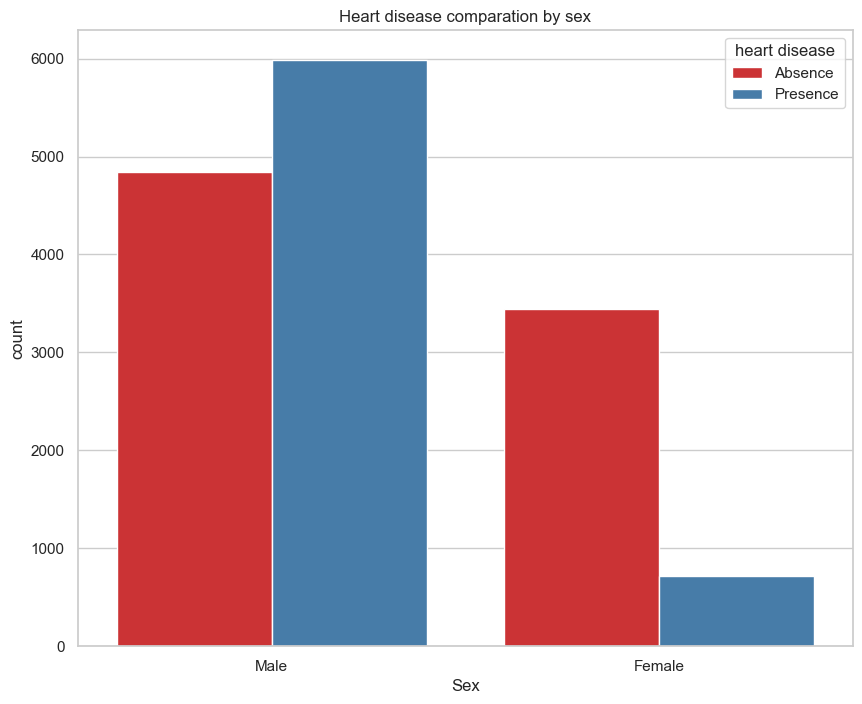

In [79]:
##  Data visualizion for catigorical dataset
##  show the comparation between male and female
plt.figure(figsize=(10,8))
sns.countplot(x='Sex', hue='Heart Disease', data=small_data, palette='Set1')
plt.title('Heart disease comparation by sex')

plt.xlabel('Sex')
plt.ylabel('count')
plt.legend(title='heart disease')
plt.show()

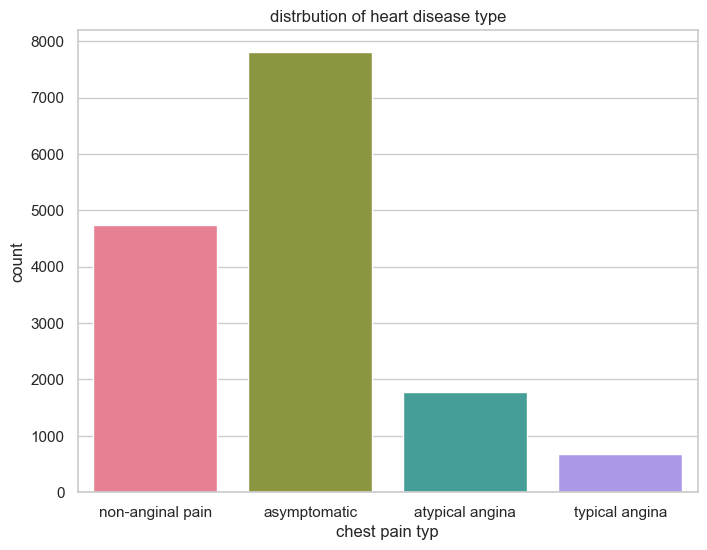

In [80]:
## 4.3.2 show distribution of chest pain type
plt.figure(figsize=(8,6))
sns.countplot(x='Chest pain type',hue='Chest pain type',data =small_data,palette='husl')
plt.title('distrbution of heart disease type')
plt.xlabel('chest pain typ')
plt.ylabel('count')

plt.show()

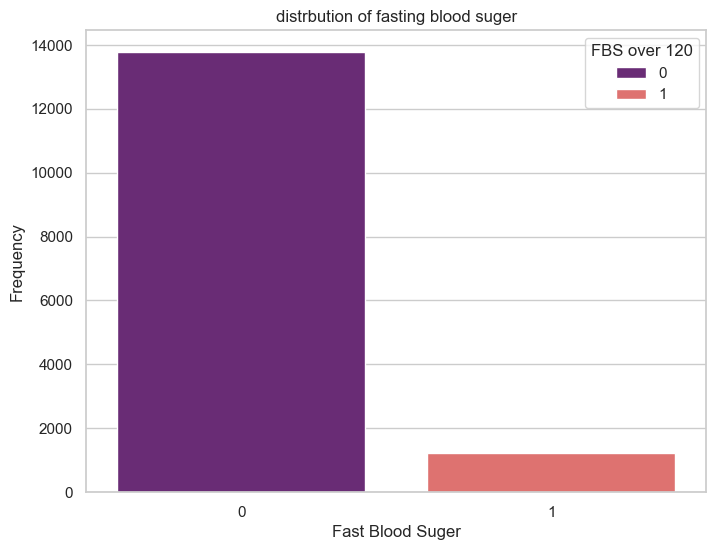

In [81]:
## 4.3.3 distrbution of Distribution of Fasting Blood Sugar (1: >120 mg/dl, 0: <120 mg/dl)'
plt.figure(figsize=(8,6))
sns.countplot(x='FBS over 120',hue='FBS over 120',data=small_data,palette="magma")
plt.title('distrbution of fasting blood suger')
plt.xlabel('Fast Blood Suger')
plt.ylabel('Frequency')
plt.show()

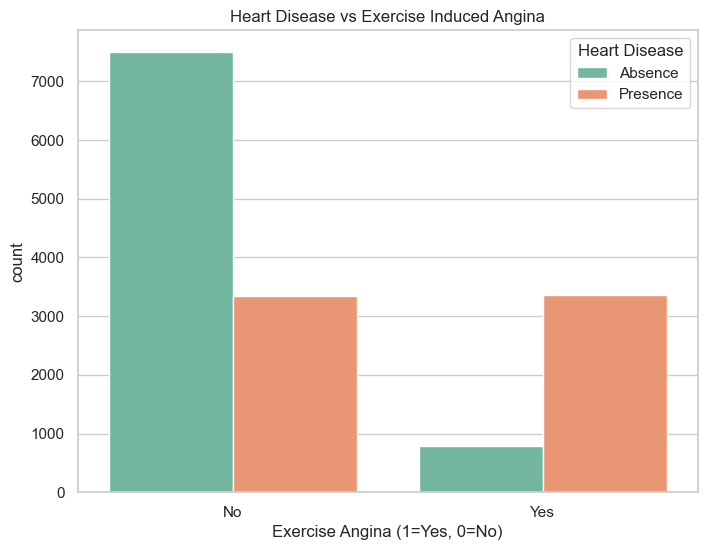

In [82]:
## 4.3.4 distribution of exersice Exercise angina
plt.figure(figsize=(8,6))
sns.countplot(x='Exercise angina', hue='Heart Disease', data=small_data, palette='Set2')

plt.title('Heart Disease vs Exercise Induced Angina')
plt.xlabel('Exercise Angina (1=Yes, 0=No)')
plt.legend(title='Heart Disease')
plt.show()


horizontal bar chart

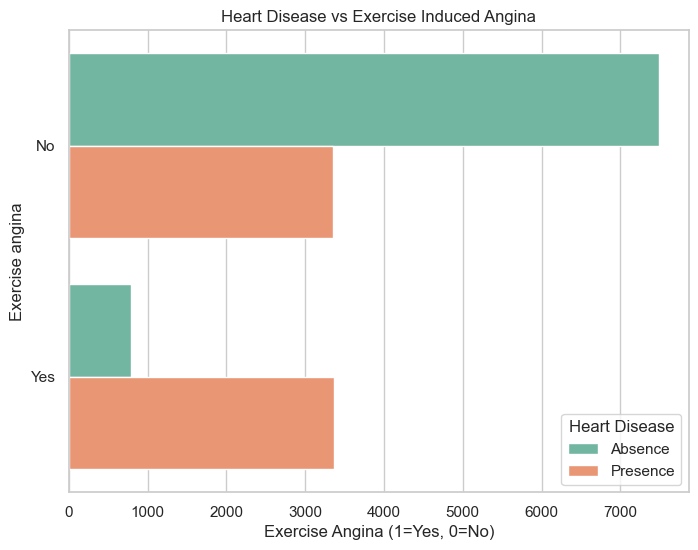

In [83]:
## distribution of exersice Exercise angina with horizontal
plt.figure(figsize=(8,6))
sns.countplot(y='Exercise angina', hue='Heart Disease', data=small_data, palette='Set2')

plt.title('Heart Disease vs Exercise Induced Angina')
plt.xlabel('Exercise Angina (1=Yes, 0=No)')
plt.legend(title='Heart Disease')
plt.show()

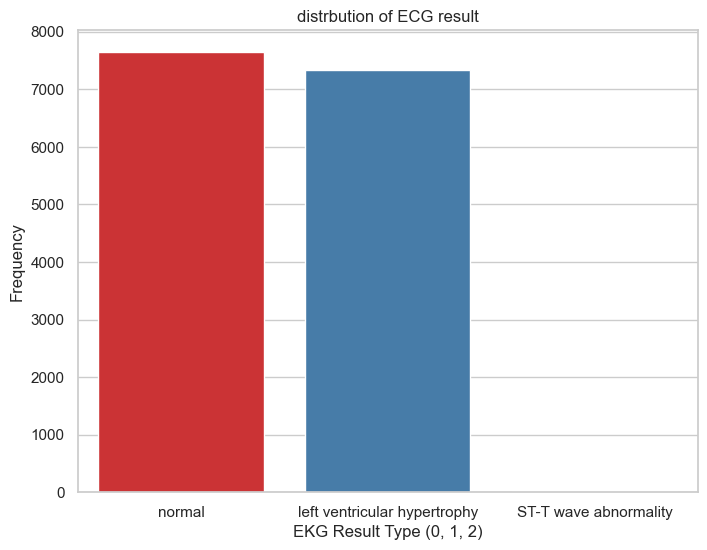

In [84]:
##  Electrocardiogram distrbution
plt.figure(figsize=(8,6))
sns.countplot(x='EKG results',hue='EKG results',data=small_data,palette='Set1')
plt.title('distrbution of ECG result')
plt.xlabel(('EKG Result Type (0, 1, 2)'))
plt.ylabel('Frequency')
plt.show()

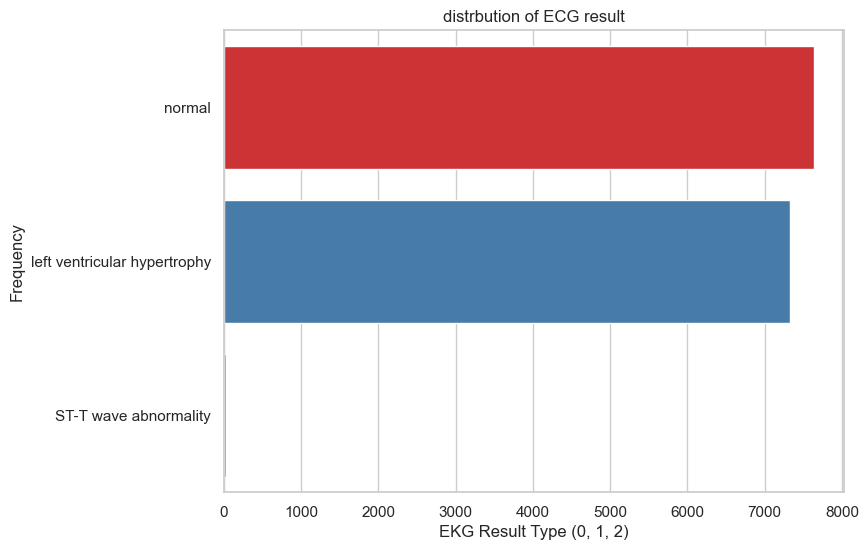

In [85]:
##  Electrocardiogram distrbution with horizontal
plt.figure(figsize=(8,6))
sns.countplot(y='EKG results',hue='EKG results',data=small_data,palette='Set1')
plt.title('distrbution of ECG result')
plt.xlabel(('EKG Result Type (0, 1, 2)'))
plt.ylabel('Frequency')
plt.show()

## pichart used to part to whole relationship

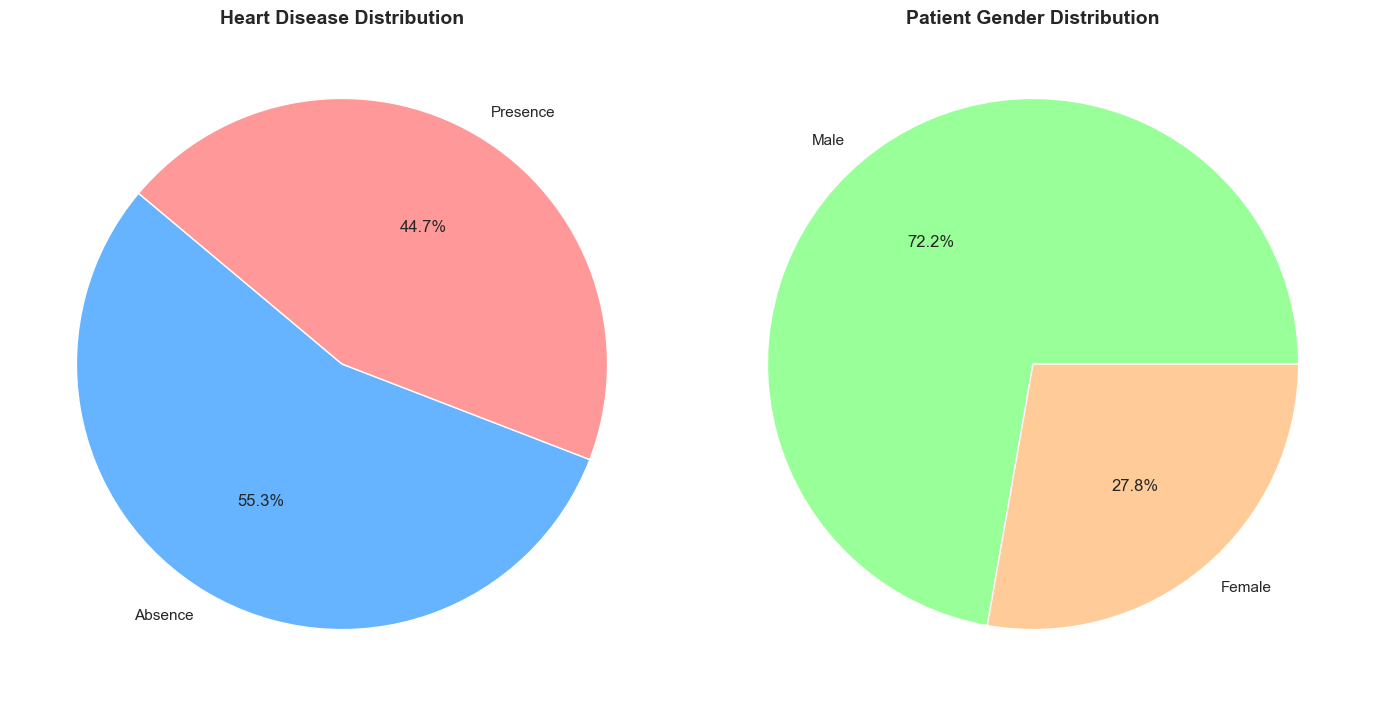

In [86]:
## Categorical Distribution Visualization (Pie Charts)
##Visualizing the ratio of Heart Disease cases and the Gender distribution within the dataset
target_counts = small_data['Heart Disease'].value_counts()

# 2. Prepare data for Gender distribution
sex_counts = small_data['Sex'].value_counts()

# Create a figure with two pie charts side-by-side
plt.figure(figsize=(14, 7))

# --- Chart 1: Heart Disease Status ---
plt.subplot(1, 2, 1) # 1 row, 2 columns, index 1
plt.pie(target_counts,
        labels=target_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=['#66b3ff','#ff9999'],
       ) # "Explode" pulls the first slice out slightly
plt.title('Heart Disease Distribution', fontsize=14, fontweight='bold')

# --- Chart 2: Gender Distribution ---
plt.subplot(1, 2, 2) # 1 row, 2 columns, index 2
plt.pie(sex_counts,
        labels=sex_counts.index,
        autopct='%1.1f%%',
        
        colors=['#99ff99','#ffcc99'],
       )
plt.title('Patient Gender Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

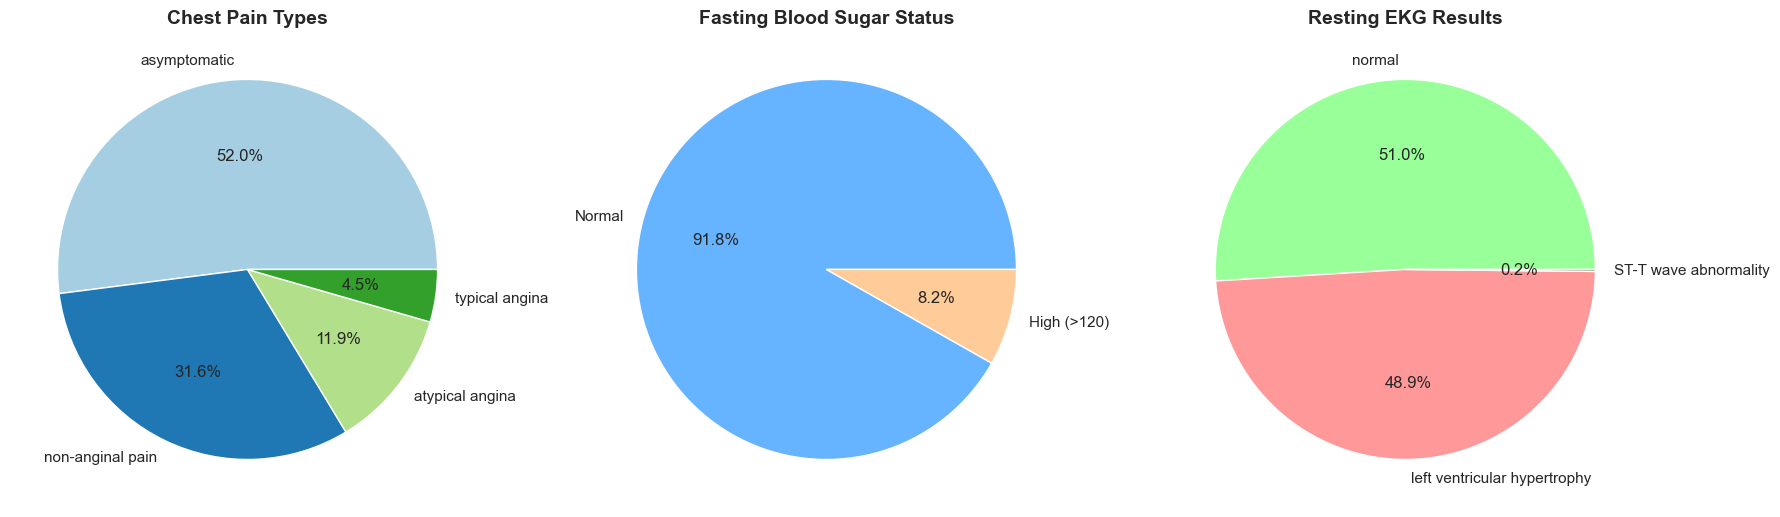

In [87]:
## Clinical Feature Distribution (Categorical Pie Charts)
### Visualizing the distribution of Chest Pain types, Fasting Blood Sugar, and EKG results to understand the dataset composition.

# Prepare data for 3 clinical features
cp_counts = small_data['Chest pain type'].value_counts()
fbs_counts = small_data['FBS over 120'].value_counts()
ekg_counts = small_data['EKG results'].value_counts()

# Create a figure with three pie charts in a row
plt.figure(figsize=(18, 6))

# --- Chart 1: Chest Pain Type ---
plt.subplot(1, 3, 1)
plt.pie(cp_counts, labels=cp_counts.index, autopct='%1.1f%%', 
        colors=plt.cm.Paired.colors)
plt.title('Chest Pain Types', fontsize=14, fontweight='bold')

# --- Chart 2: Fasting Blood Sugar (FBS > 120 mg/dl) ---
plt.subplot(1, 3, 2)
plt.pie(fbs_counts, labels=['Normal', 'High (>120)'], autopct='%1.1f%%',
         colors=['#66b3ff','#ffcc99'])
plt.title('Fasting Blood Sugar Status', fontsize=14, fontweight='bold')

# --- Chart 3: EKG Results ---
plt.subplot(1, 3, 3)
plt.pie(ekg_counts, labels=ekg_counts.index, autopct='%1.1f%%',
         colors=['#99ff99','#ff9999','#808080'])
plt.title('Resting EKG Results', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [88]:
small_data.columns

Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease'],
      dtype='object')

## visualize the distribution of dataset with histogram

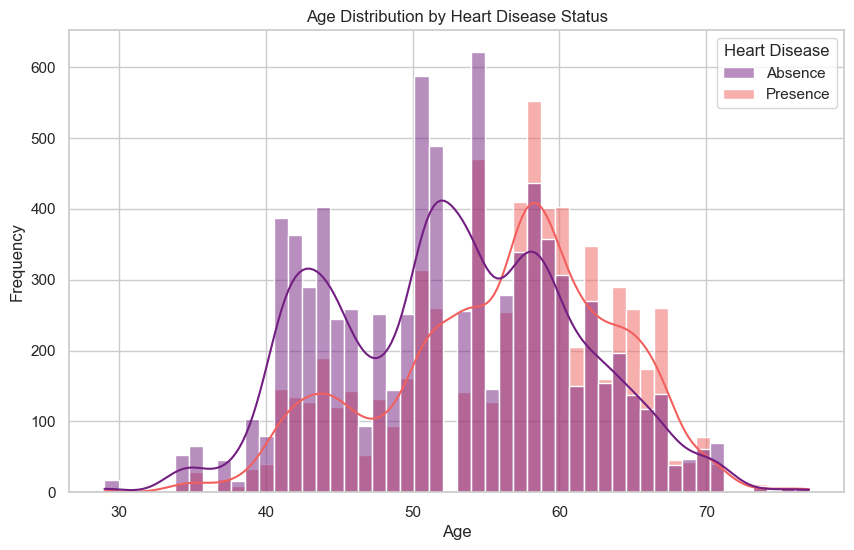

In [89]:
## visualize age by histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=small_data, x='Age', hue='Heart Disease', kde=True, palette='magma' )
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

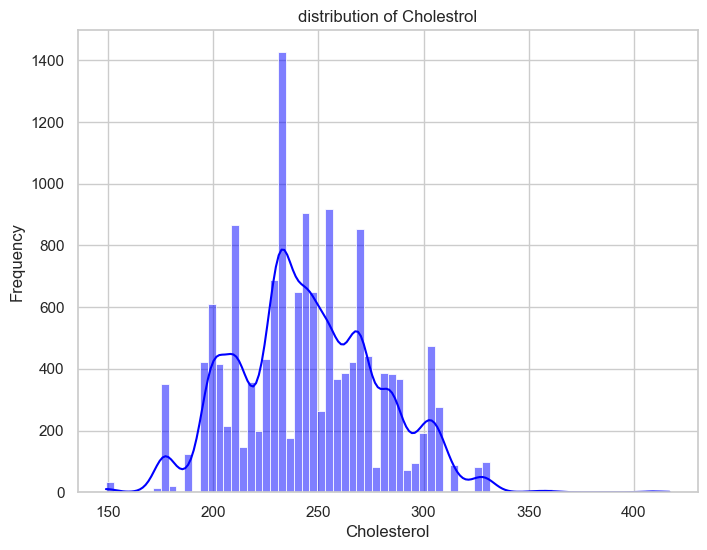

In [90]:
## distrbution of cholesterol
plt.figure(figsize=(8,6))
sns.histplot( data=small_data,x='Cholesterol', kde='True',color='blue')
plt.title('distribution of Cholestrol')
plt.xlabel('Cholesterol')
plt.ylabel('Frequency')
plt.show()

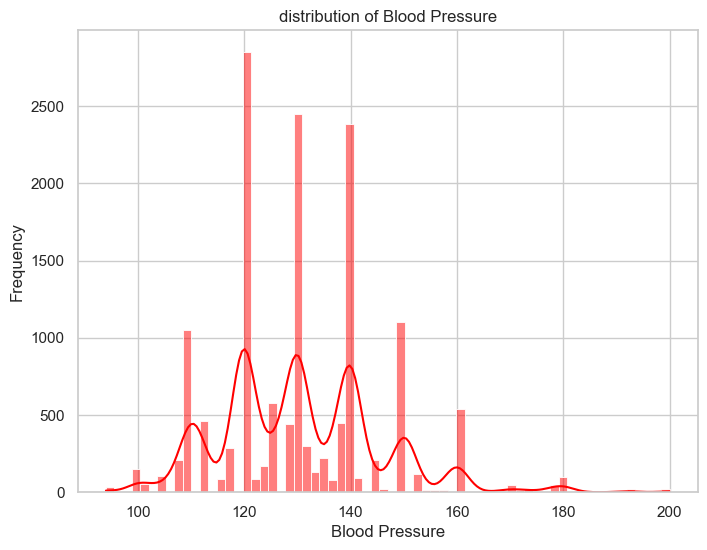

In [91]:
## visulizing Blood Pressure
plt.figure(figsize=(8,6))
sns.histplot(small_data['BP'],kde='True', color='red')
plt.title('distribution of Blood Pressure')
plt.xlabel('Blood Pressure')
plt.ylabel('Frequency')
plt.show()

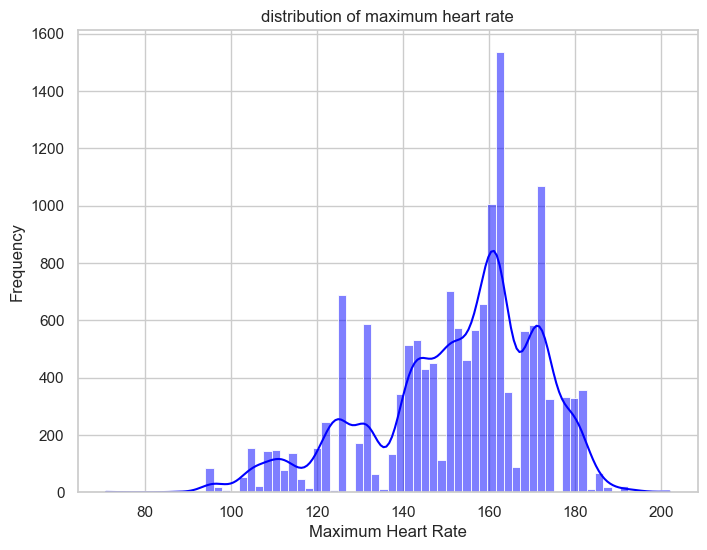

In [92]:
## visualzing Maximum heart rate
plt.figure(figsize=(8,6))
sns.histplot( data=small_data,x='Max HR',kde='True',color='blue')
plt.title('distribution of maximum heart rate')
plt.xlabel('Maximum Heart Rate')
plt.ylabel("Frequency")
plt.show()

In [93]:
small_data.columns

Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease'],
      dtype='object')

## linechart

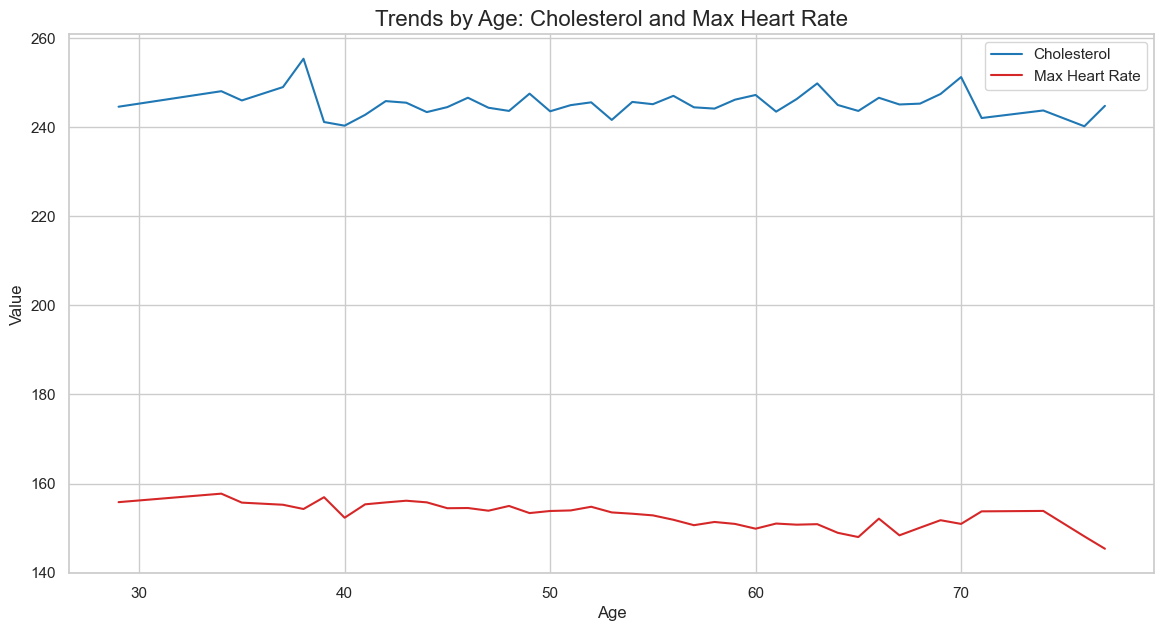

In [94]:
## Visualizing the relationship between Age, Cholesterol, and Max Heart Rate

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# Using the exact column names from your list
sns.lineplot(x='Age', y='Cholesterol', data=small_data, label='Cholesterol', color='#1f77b4',errorbar=None)
sns.lineplot(x='Age', y='Max HR', data=small_data, label='Max Heart Rate', color='#d62728',errorbar=None)

plt.title('Trends by Age: Cholesterol and Max Heart Rate', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend()

plt.show()

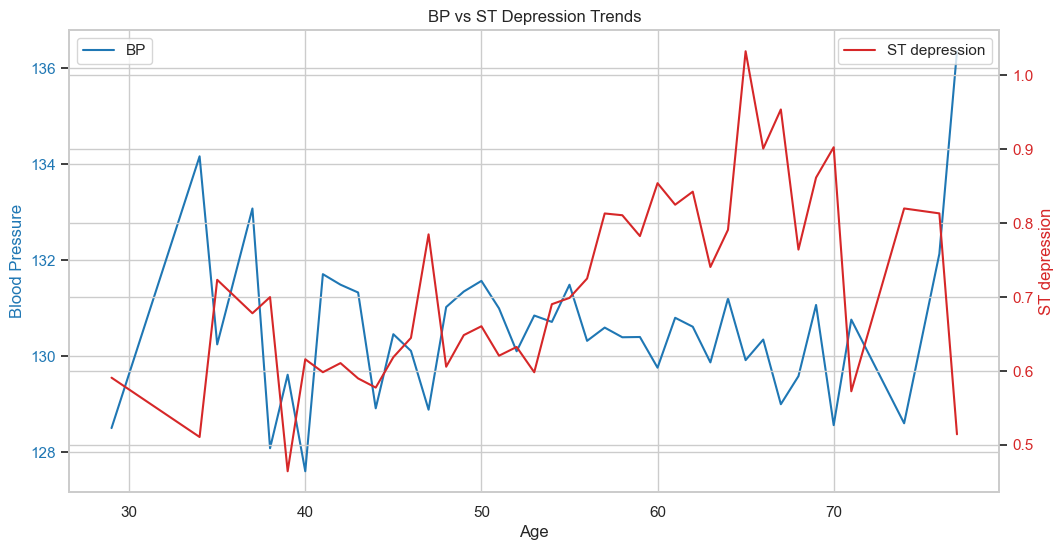

In [95]:
##Dual-Axis Trend Visualization (BP vs. ST Depression)
## analyzes how Blood Pressure (BP) and ST Depression correlate with Age using a dual-axis line chart to handle different measurement scales.
fig, ax1 = plt.subplots(figsize=(12, 6))

# First Axis (Left)
ax1.set_xlabel('Age')
ax1.set_ylabel('Blood Pressure', color='tab:blue')
sns.lineplot(x='Age', y='BP', data=small_data, ax=ax1, color='tab:blue', label='BP',errorbar=None)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Second Axis (Right)
ax2 = ax1.twinx()
ax2.set_ylabel('ST depression', color='tab:red')
sns.lineplot(x='Age', y='ST depression', data=small_data, ax=ax2, color='tab:red', label='ST depression',errorbar=None)
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('BP vs ST Depression Trends')
plt.show()

## distribution of all numerical dataset

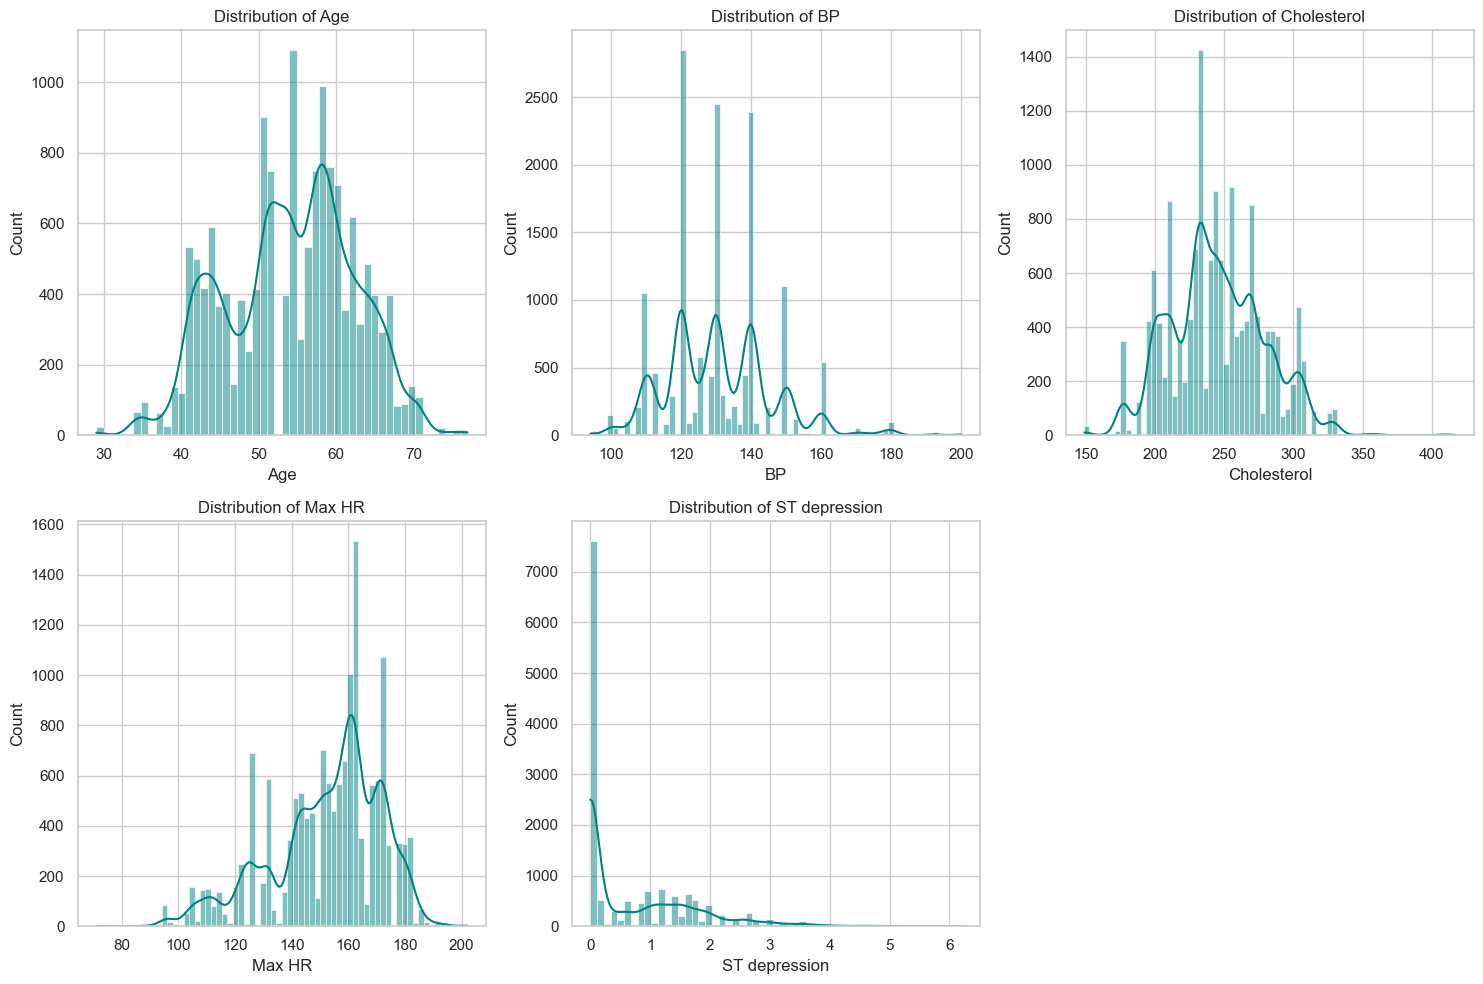

In [96]:
## distribution of all numerical dataset

# List of continuous columns
hist = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

# Set up the figure size
plt.figure(figsize=(15, 10))

# Loop through each column and create a histogram
for i, col in enumerate(hist):
    plt.subplot(2, 3, i + 1)  # Create a 2x3 grid
    sns.histplot(small_data[col], kde=True, color='teal')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()

plt.show()

## scatter plot:is used to find the pattern and relationship of the data

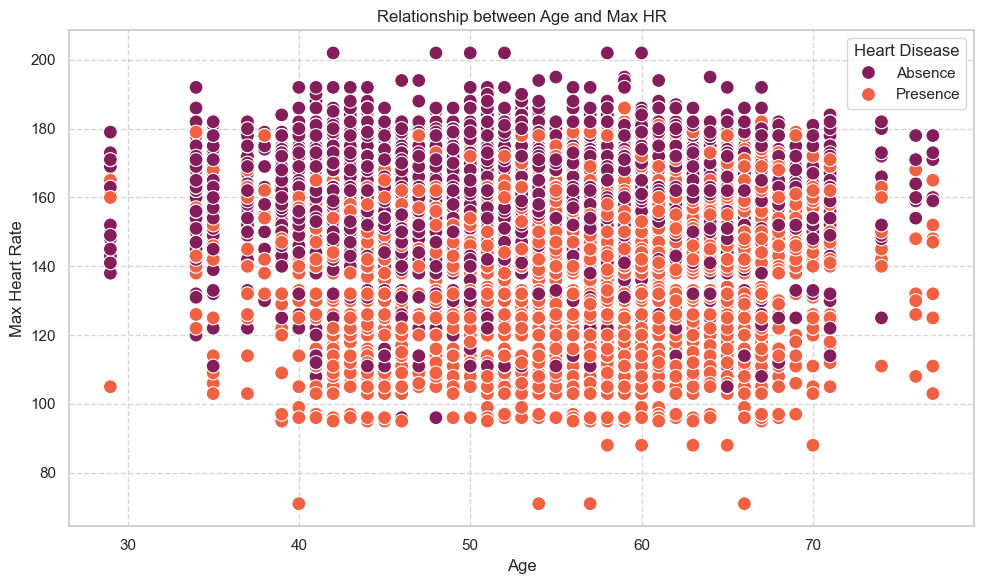

In [97]:
## visualizing the reletion beteewn Age and Max HR using scattorplot

# scatterplot
plt.figure(figsize=(10, 6))

sns.scatterplot(data=small_data, x='Age', y='Max HR',  hue='Heart Disease', palette='rocket', s=100)

plt.title('Relationship between Age and Max HR')
plt.xlabel('Age')
plt.ylabel('Max Heart Rate')
plt.grid(True, linestyle='--', alpha=0.8)
plt.tight_layout()


plt.show()



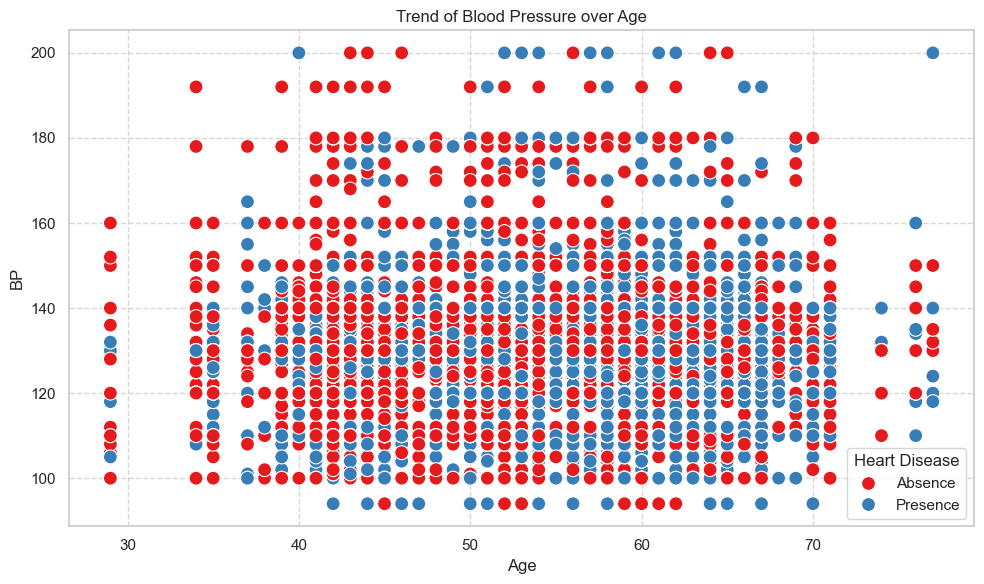

In [98]:
## visualizing the relationship between Age and Blood Pressure using scatterplot
plt.figure(figsize=(10,6))
sns.scatterplot(data=small_data,x='Age',y='BP',hue='Heart Disease', palette='Set1',s=100)
plt.title('Trend of Blood Pressure over Age')
plt.grid(True,linestyle='--',alpha=0.8)
plt.tight_layout()
plt.show()

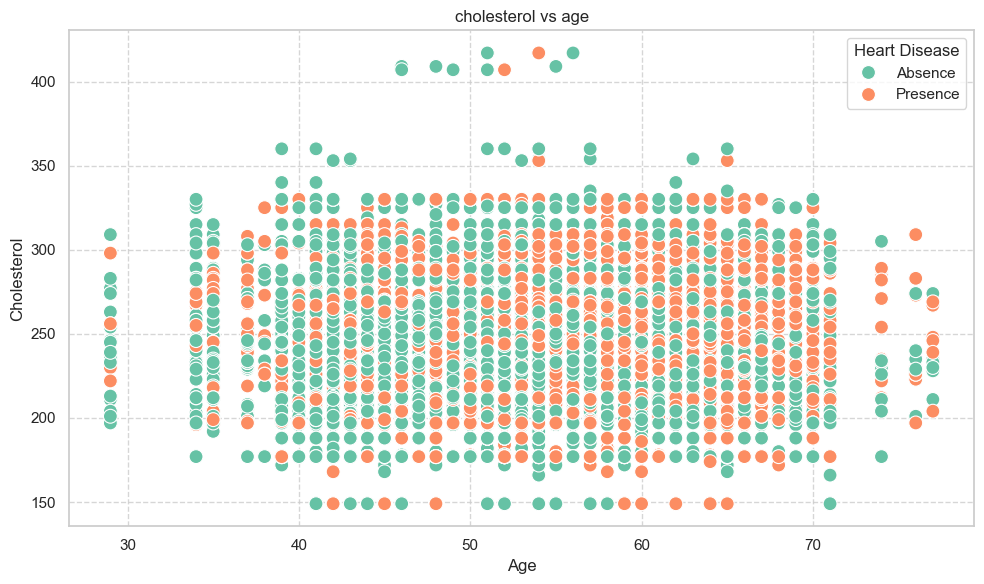

In [99]:
## visualising the correlation between age and cholestrol using scather plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=small_data,x='Age',y='Cholesterol',hue='Heart Disease',palette='Set2',s=100)
plt.title('cholesterol vs age')
plt.grid(True,linestyle='--',alpha=0.8)
plt.tight_layout()
plt.show()

## heatmap:that used to show the correletion beteween dataset

Text(0.5, 1.0, 'correlation heatmap')

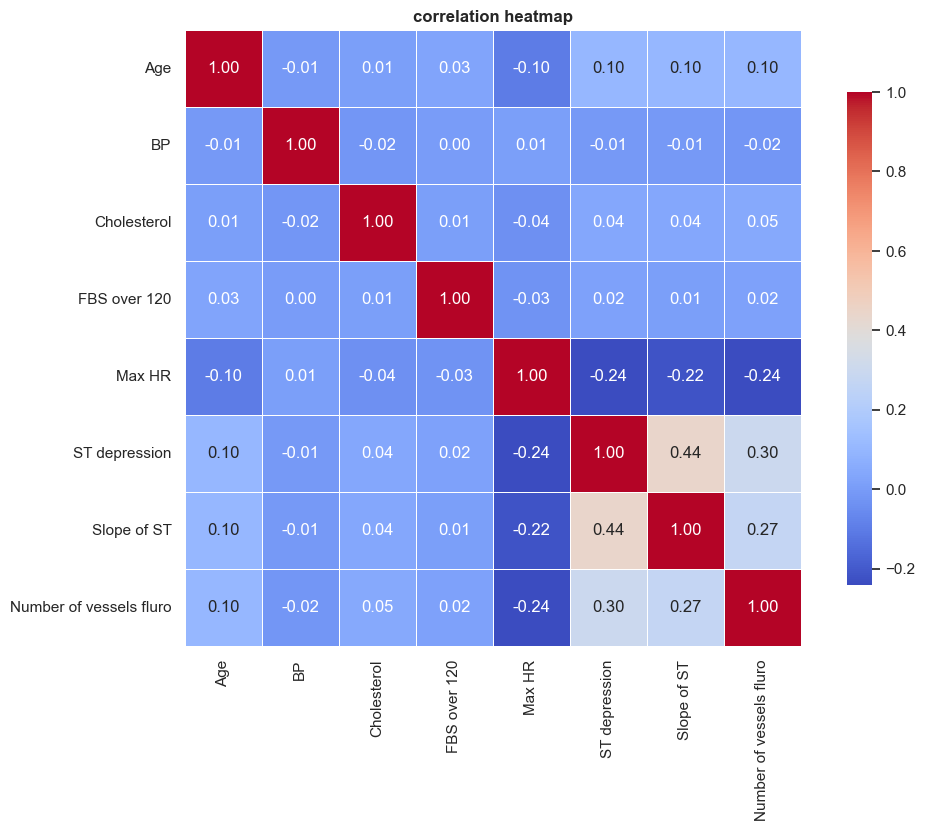

In [100]:
## Calculate the Pearson correlation matrix
### We round to 2 decimal places for better readability in the char
num_data=small_data.select_dtypes(include=[np.number]).drop(columns=['id'],errors='ignore')
correlation=num_data.corr().round(2)

plt.figure(figsize=(12, 8))
# 6. Generate the heatmap
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, square=True, cbar_kws={"shrink": .8})
plt.title('correlation heatmap',fontweight='bold')

## data cleaning and preprocessing

## outleir detection

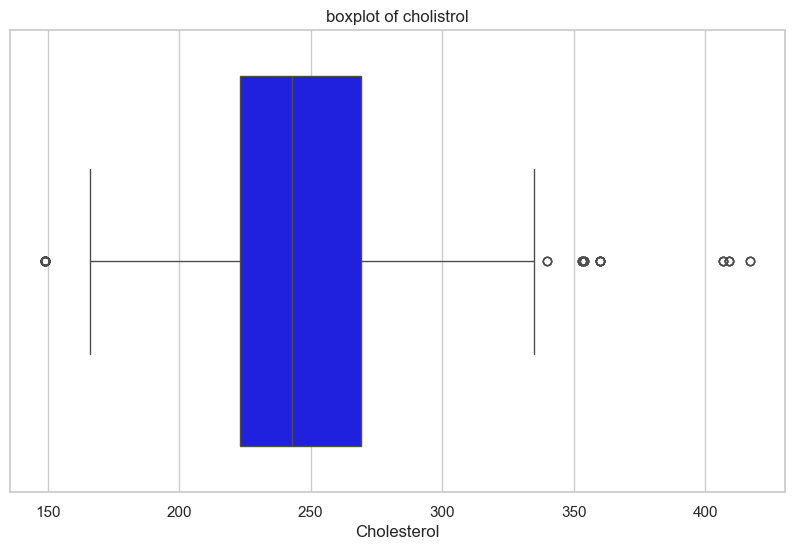

In [101]:
## detect the outlier of cholesterol
plt.figure(figsize=(10,6))
sns.boxplot(x=small_data['Cholesterol'],color ='blue')
plt.title('boxplot of cholistrol')
plt.show()

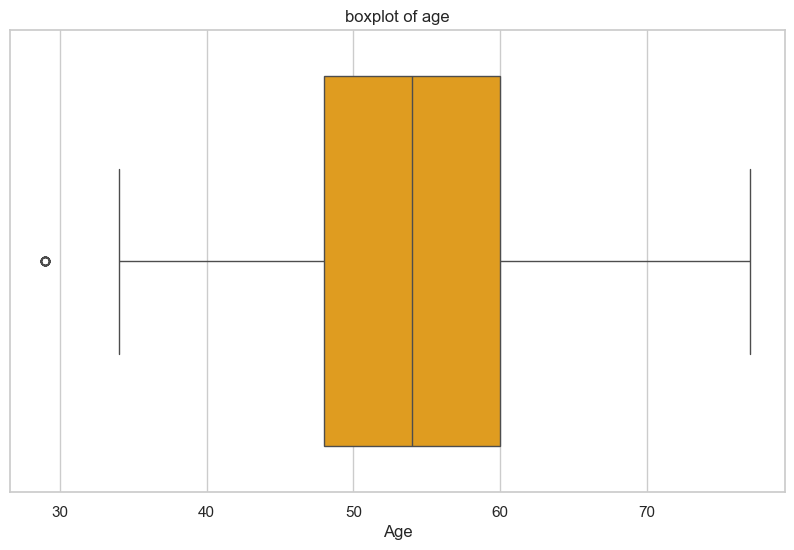

In [102]:
## detect outlier of age
plt.figure(figsize=(10,6))
sns.boxplot(x=small_data['Age'],color='orange')
plt.title('boxplot of age')
plt.show()


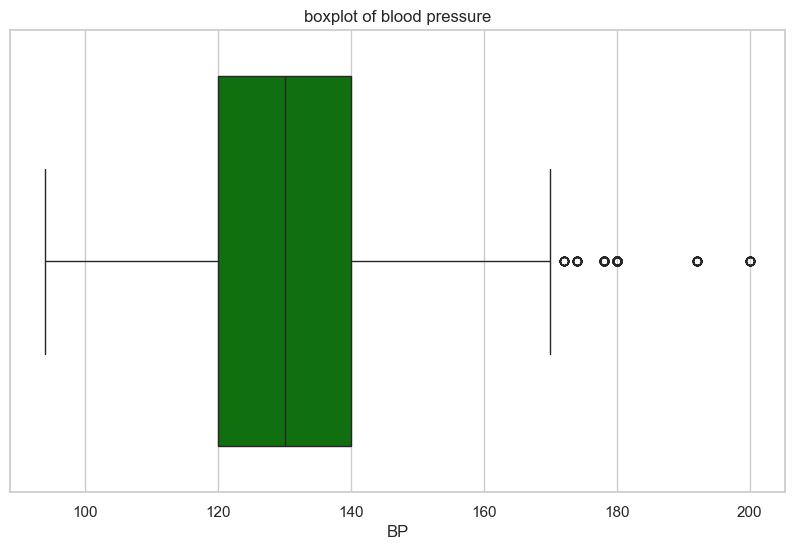

In [103]:
## outliers of Blood Pressure
plt.figure(figsize=(10,6))
sns.boxplot(x=small_data['BP'],color='green')
plt.title('boxplot of blood pressure')
plt.show()


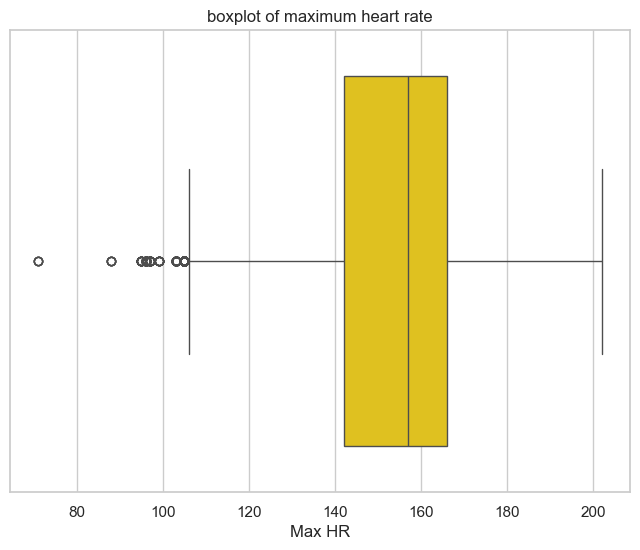

In [104]:
## outlier of Maximem heart rate
plt.figure(figsize=(8,6))
sns.boxplot(x=small_data['Max HR'],color='gold')
plt.title('boxplot of maximum heart rate')
plt.show()


## filling missing value

In [105]:
small_data.isnull().sum()

id                         0
Age                        5
Sex                        0
Chest pain type            0
BP                         3
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     1
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [106]:
## fill missing or imputation  value of age
small_data['Age']=small_data['Age'].fillna(small_data['Age'].median())




In [107]:
## imputation of missing value ov blood pressur
small_data['BP']=small_data['BP'].fillna(small_data['BP']).median()

In [108]:
## imputation of missing value of max rate
small_data=small_data.fillna(small_data['Max HR'].median)

In [109]:
small_data.isnull().sum()

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

##  Dataset Optimization

In [110]:
##  Dataset Optimization
# We create a deep copy of the first 15,000 records.
# .copy() ensures that changes to 'small_data' do not affect the original dataframe.
small_data = small_data.head(15000).copy()

small_data['Max HR'] = pd.to_numeric(small_data['Max HR'], errors='coerce')

# 3. Fill any missing values in 'Max HR' with the median to keep the column complete
small_data['Max HR'] = small_data['Max HR'].fillna(small_data['Max HR'].median())

# 4. List the column names we want to clean
numerical_cols = ['Age', 'BP', 'Cholesterol', 'Max HR']

# 5. Start a loop to process each column one by one
for i in numerical_cols:
    # Calculate the 95th percentile (the value below which 95% of data falls)
    upper_limit = small_data[i].quantile(0.95)

    # Calculate the 5th percentile (the value below which 5% of data falls)
    lower_limit = small_data[i].quantile(0.05)

    small_data[i] = small_data[i].clip(lower=lower_limit, upper=upper_limit)

# 6. Print the statistical summary to verify the changes
print(small_data[numerical_cols].describe())

                Age       BP   Cholesterol       Max HR
count  15000.000000  15000.0  15000.000000  15000.00000
mean      54.155533    130.0    245.249200    152.86740
std        7.735623      0.0     30.882088     18.01872
min       41.000000    130.0    197.000000    114.00000
25%       48.000000    130.0    223.000000    142.00000
50%       54.000000    130.0    243.000000    157.00000
75%       60.000000    130.0    269.000000    166.00000
max       67.000000    130.0    303.000000    179.00000


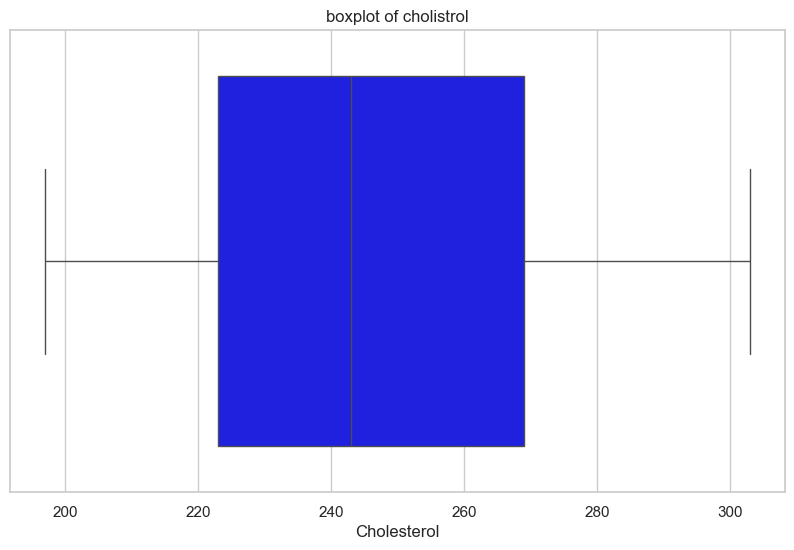

In [111]:
## detect the outlier of cholesterol after outlier managmen
plt.figure(figsize=(10,6))
sns.boxplot(x=small_data['Cholesterol'],color ='blue')
plt.title('boxplot of cholistrol')
plt.show()


#  Categorical Encoding (Mapping)

In [112]:

#  Categorical Encoding (Mapping)
# We convert text-based categories into numerical values.
# This is required because most machine learning algorithms cannot process raw text.
df=pd.read_csv('heart_raw.csv')


# 2. Convert text data to numbers (Mapping) - This is required before using astype(int)
df['Sex']=df['Sex'].map({'Male':1,'Female':0})
df['Chest pain type']=df['Chest pain type'].map({'asymptomatic': 1,'typical angina': 2,
    'atypical angina': 3,'non-anginal pain': 4})
df['EKG results']=df['EKG results'].map({'normal': 1,
    'left ventricular hypertrophy': 2,'ST-T wave abnormality': 3})
df['Exercise angina']=df['Exercise angina'].map({'No':0,'Yes':1})
df['Thallium']=df['Thallium'].map({'normal':1,'reversable defect':2,'fixed defect': 3})
df['Heart Disease']=df['Heart Disease'].map({'Absence':0,'Presence':1})
# 3. Robust Missing Value Imputation
# If any text didn't match our map, it becomes a NaN (Not a Number).
# We fill NaNs with the most frequent value (Mode) of each column.
for col in df.columns:
    col_mode = df[col].mode()
    if not col_mode.empty:
        # Fill missing values with the first mode found
        df[col] = df[col].fillna(col_mode[0])
    else:
        # Safety net: If a column is completely empty, fill with 0 to avoid errors
       df[col] = df[col].fillna(0)
print(df.head())


   id   Age  Sex  Chest pain type     BP  Cholesterol  FBS over 120  \
0   0  58.0    1                1  152.0        239.0             0   
1   1  52.0    1                2  125.0        325.0             0   
2   2  56.0    0                3  160.0        188.0             0   
3   3  44.0    0                4  134.0        229.0             0   
4   4  58.0    1                1  140.0        234.0             0   

   EKG results  Max HR  Exercise angina  ST depression  Slope of ST  \
0            1   158.0                1            3.6            2   
1            2   171.0                0            0.0            1   
2            2   151.0                0            0.0            1   
3            2   150.0                0            1.0            2   
4            2   125.0                1            3.8            2   

   Number of vessels fluro  Thallium  Heart Disease  
0                        2         2              1  
1                        0         1  

In [113]:
df.info() ## check structre

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630020 entries, 0 to 630019
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630020 non-null  int64  
 1   Age                      630020 non-null  float64
 2   Sex                      630020 non-null  int64  
 3   Chest pain type          630020 non-null  int64  
 4   BP                       630020 non-null  float64
 5   Cholesterol              630020 non-null  float64
 6   FBS over 120             630020 non-null  int64  
 7   EKG results              630020 non-null  int64  
 8   Max HR                   630020 non-null  float64
 9   Exercise angina          630020 non-null  int64  
 10  ST depression            630020 non-null  float64
 11  Slope of ST              630020 non-null  int64  
 12  Number of vessels fluro  630020 non-null  int64  
 13  Thallium                 630020 non-null  int64  
 14  Hear

In [114]:

df.head(10) ## show 10 sample dataset

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58.0,1,1,152.0,239.0,0,1,158.0,1,3.6,2,2,2,1
1,1,52.0,1,2,125.0,325.0,0,2,171.0,0,0.0,1,0,1,0
2,2,56.0,0,3,160.0,188.0,0,2,151.0,0,0.0,1,0,1,0
3,3,44.0,0,4,134.0,229.0,0,2,150.0,0,1.0,2,0,1,0
4,4,58.0,1,1,140.0,234.0,0,2,125.0,1,3.8,2,3,1,1
5,5,38.0,1,1,138.0,283.0,0,1,147.0,1,1.6,2,2,2,1
6,6,59.0,1,1,130.0,246.0,0,2,152.0,0,0.8,2,2,1,1
7,7,60.0,0,4,120.0,245.0,0,1,151.0,0,1.2,1,0,1,0
8,8,48.0,0,1,140.0,212.0,0,2,125.0,0,0.0,1,0,1,0
9,9,44.0,0,1,150.0,197.0,0,1,150.0,0,0.0,2,0,1,0


## feature selection

In [115]:
# 1. Drop columns that are not useful for the model and contain text
X=df.drop(['id','Heart Disease'],axis=1,errors='ignore')
y=df['Heart Disease']

# 2. Select only numerical columns and fill missing values with the median
numeric_only = X.select_dtypes(include=[np.number]).columns
X[numeric_only] = X[numeric_only].fillna(X[numeric_only].median())

# 3. Fill any remaining missing values (for categorical/text columns) with the mode
X = X.fillna(X.mode().iloc[0])
## prform scaling
scalre=StandardScaler()
X_scaled = scalre.fit_transform(X)
print('completed')

completed


## select and train the machin learning model

## LogisticRegression model for heart disease pridiction

In [116]:
## LogisticRegression model for heart disease pridiction

# 1. Prepare Features and Target
# Drop 'id' because it's irrelevant, and 'Heart Disease' because it's the label
X = df.drop(['id', 'Heart Disease'], axis=1, errors='ignore')
y = df['Heart Disease']

# 2. Convert categorical text to numeric using One-Hot Encoding
# This is crucial for Logistic Regression to treat categories fairly
X = pd.get_dummies(X, drop_first=True)

# 3. Split the data before scaling to prevent Data Leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling (Standardization)
# Scale the data so that large numbers don't dominate the model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Fit and transform training data
X_test_scaled = scaler.transform(X_test)       # Transform test data using the training scale

# 5. Initialize and Train the Logistic Regression model
# Increased max_iter to ensure the model converges properly
model = LogisticRegression(max_iter=1000)

# Training happens on the SCALED data
model.fit(X_train_scaled, y_train)

print('Training completed successfully with scaled and encoded data!')

Training completed successfully with scaled and encoded data!


In [117]:
## model prediction
prediction = model.predict(X_test_scaled)
print(prediction[:20])

[0 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 1 0]


In [118]:

## example of LogisticRegression
new_data = {
    'Age': [55],
    'Sex': [1],
    'Chest pain type': [3],
    'BP': [140],
    'Cholesterol': [250],
    'FBS over 120': [0],
    'EKG results': [1],
    'Max HR': [150],
    'Exercise angina': [0],
    'ST depression': [2.5],
    'Slope of ST': [2],
    'Number of vessels fluro': [0],
      'Thallium': [3]}
      ## convert to dataframe
single_patient_df=pd.DataFrame(new_data)
      # 3. Predict (This will not show the warning/error)
result = model.predict(single_patient_df.values)

if result[0] == 1:
    print("Prediction: High Risk of Heart Disease")
else:
    print("Prediction: presence")


Prediction: presence


## model evalution of LogisticRegression

In [119]:
## model evalution of LogisticRegression


# 1.  Use the SCALED test data for prediction
# Also, using the array version (X_test_scaled) avoids the 'UserWarning' about feature names.
y_pred = model.predict(X_test_scaled)

# 2. Calculate and print the Accuracy Score
print('logusticRegrassion training and prediction completed successfully!')
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# 3. Create and display the Confusion Matrix
# This helps us see how many patients were misdiagnosed.
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# 4. Print the Detailed Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

logusticRegrassion training and prediction completed successfully!
Model Accuracy: 88.07%

Confusion Matrix:
[[62543  6697]
 [ 8340 48424]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     69240
           1       0.88      0.85      0.87     56764

    accuracy                           0.88    126004
   macro avg       0.88      0.88      0.88    126004
weighted avg       0.88      0.88      0.88    126004



In [120]:
## check cross_validion of the logisticregression model

# 1. Scale the features (X) first
# Scaling helps the solver converge much faster and stops the warnings
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Re-initialize the model
# Now that data is scaled, 1000 iterations will be more than enough
model_cv = LogisticRegression(max_iter=12000)

# 3. Perform Cross-Validation on the scaled data
scores = cross_val_score(model_cv, X_scaled, y, cv=5)

# 4. Results
print(f"Scores for each fold: {scores}")
print(f"Average Cross-Validation Accuracy: {scores.mean() * 100:.2f}%")

Scores for each fold: [0.88196406 0.88080537 0.88165455 0.88102759 0.88121012]
Average Cross-Validation Accuracy: 88.13%


## KNN model

In [121]:
## KNN model

# 1. Feature Scaling - VERY IMPORTANT for KNN
scaler = StandardScaler()

# Fit and transform ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# ONLY transform the test data (Do not fit!)
X_test_scaled = scaler.transform(X_test)

# 2. Initialize KNN model
# n_neighbors=5 is a standard start, but can be tuned later
knn = KNeighborsClassifier(n_neighbors=5,n_jobs=-1)

# 3. Train the model using the SCALED training data
knn.fit(X_train_scaled, y_train)

# 4. Make predictions
y_pred_knn = knn.predict(X_test_scaled)

print('KNN training and prediction completed successfully!')

# 5. Evaluate the results
print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

KNN training and prediction completed successfully!
KNN Accuracy: 86.91%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     69240
           1       0.86      0.85      0.85     56764

    accuracy                           0.87    126004
   macro avg       0.87      0.87      0.87    126004
weighted avg       0.87      0.87      0.87    126004



In [122]:
## example
new_data = {
    'Age': [55],
    'Sex': [1],
    'Chest pain type': [3],
    'BP': [140],
    'Cholesterol': [250],
    'FBS over 120': [0],
    'EKG results': [1],
    'Max HR': [150],
    'Exercise angina': [0],
    'ST depression': [2.5],
    'Slope of ST': [2],
    'Number of vessels fluro': [0],
      'Thallium': [3]}
      ## convertt to dataframe
single_patient_df=pd.DataFrame(new_data)
result=model.predict(single_patient_df.values)
if result[0]==1:
        print('presence')
else:
         print('absence')

absence


In [123]:
 ## cross validation of knn

from sklearn.pipeline import Pipeline


# 1. Create a Pipeline: First Scale the data, then apply KNN
# This ensures that validation data is not "leaked" during scaling
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=3))
])

# 2. Perform 5-Fold Cross-Validation
# We use the whole X and y here
cv_scores = cross_val_score(pipeline, X, y, cv=5, n_jobs=-1)

# 3. Output results
print(f"All Scores: {cv_scores}")
print(f"Average CV Accuracy: {cv_scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {cv_scores.std():.4f}")

All Scores: [0.86155201 0.86070283 0.86030602 0.85959176 0.86160757]
Average CV Accuracy: 86.08%
Standard Deviation: 0.0008


## random forest

In [124]:
## random forest


# 1. Initialize the Random Forest model
# Note: For a serious project, use GridSearchCV to find the best parameters
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,          # Adjusted for better generalization
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced' # Important if you have more healthy people than patients
)

# 2. Train the model using the CORRECT variable names (Uppercase X)
# Use the same preprocessed/encoded X_train you used for Logistic Regression
rf_model.fit(X_train, y_train)

# 3. Predict on the test data (Uppercase X)
y_pred_rf = rf_model.predict(X_test)

# 4. Evaluation
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# 5. Focus on Recall in the Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 88.52%

Confusion Matrix:
[[61597  7643]
 [ 6817 49947]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.89     69240
           1       0.87      0.88      0.87     56764

    accuracy                           0.89    126004
   macro avg       0.88      0.88      0.88    126004
weighted avg       0.89      0.89      0.89    126004



In [125]:
## example
import pandas as pd
new_data = {
    'Age': [55],
    'Sex': [1],
    'Chest pain type': [3],
    'BP': [140],
    'Cholesterol': [250],
    'FBS over 120': [0],
    'EKG results': [1],
    'Max HR': [150],
    'Exercise angina': [0],
    'ST depression': [2.5],
    'Slope of ST': [2],
    'Number of vessels fluro': [0],
      'Thallium': [3]}
      ## convertt to dataframe
single_patient_df=pd.DataFrame(new_data)
result=model.predict(single_patient_df.values)
if result[0]==1:
        print('presence')
else:
         print('absence')

absence


In [ ]:
## cross validation


# 1. Initialize the Random Forest model with pre-defined hyperparameters
# We use the same parameters to ensure consistency across all tests
rf_heart = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_leaf=5, random_state=42)

# 2. Perform 5-Fold Cross-Validation
# This splits the training data into 5 subsets to validate the model's stability
cv_scores = cross_val_score(rf_heart, X_train, y_train, cv=5)

# 3. Output the validation results
# 'Mean CV Accuracy' shows the average performance across all 5 folds
print(f"All CV Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {cv_scores.std():.4f}")

## compare the model by making comparesion table

In [ ]:
## compare the model by making comparesion table

# Creating the dataset based on the results of the individual model
data = {
    'Metric': [
        'Accuracy',
        'Precision (Class 1)',
        'Recall (Class 1)',
        'F1-Score (Class 1)',
        'False Positives (FP)',
        'False Negatives (FN)'
    ],
    'Logistic Regression': [
        '88.07%', '88%', '85%', '87%', 6697, 8340
    ],
    'KNN': [
        '86.91%', '86%', '85%', '85%', 'N/A', 'N/A'
    ],
    'Random Forest': [
        '88.52%', '87%', '88%', '87%', 7643, 6817
    ]
}

# Initialize DataFrame
df_comparison = pd.DataFrame(data)

# Setting the Metric column as the index for a cleaner look
df_comparison.set_index('Metric', inplace=True)

# Display the table
print("--- Model Selection Comparison Table ---")
print(df_comparison)

# Optional: If you are using a Jupyter Notebook, simply use:
# display(df_comparison)

--- Model Selection Comparison Table ---
                     Logistic Regression     KNN Random Forest
Metric                                                        
Accuracy                          88.07%  86.91%        88.52%
Precision (Class 1)                  88%     86%           87%
Recall (Class 1)                     85%     85%           88%
F1-Score (Class 1)                   87%     85%           87%
False Positives (FP)                6697     N/A          7643
False Negatives (FN)                8340     N/A          6817


## model selection based on the result of the comparetion table

In [ ]:
## model selection based on the result of the comparetion table
# Select Random Forest as the primary model
final_model = rf_model

# Execute predictions using the finalized model
# X_test contains the unseen data for evaluation
y_pred = final_model.predict(X_test)


In [ ]:
## example
new_data = {
    'Age': [55],
    'Sex': [1],
    'Chest pain type': [3],
    'BP': [140],
    'Cholesterol': [250],
    'FBS over 120': [0],
    'EKG results': [1],
    'Max HR': [150],
    'Exercise angina': [0],
    'ST depression': [2.5],
    'Slope of ST': [2],
    'Number of vessels fluro': [0],
      'Thallium': [3]}
      ## convertt to dataframe
single_patient_df=pd.DataFrame(new_data)
result=model.predict(single_patient_df.values)
if result[0]==1:
        print('presence')
else:
         print('absence')

absence


# 1. Get feature importance from the Random Forest model

Feature: Thallium, Score: 0.27853
Feature: Chest pain type, Score: 0.20502
Feature: Number of vessels fluro, Score: 0.10920
Feature: Max HR, Score: 0.10016
Feature: Exercise angina, Score: 0.09348
Feature: Slope of ST, Score: 0.08134
Feature: ST depression, Score: 0.05758
Feature: Sex, Score: 0.03765
Feature: Age, Score: 0.01851
Feature: EKG results, Score: 0.00835
Feature: Cholesterol, Score: 0.00613
Feature: BP, Score: 0.00359
Feature: FBS over 120, Score: 0.00046


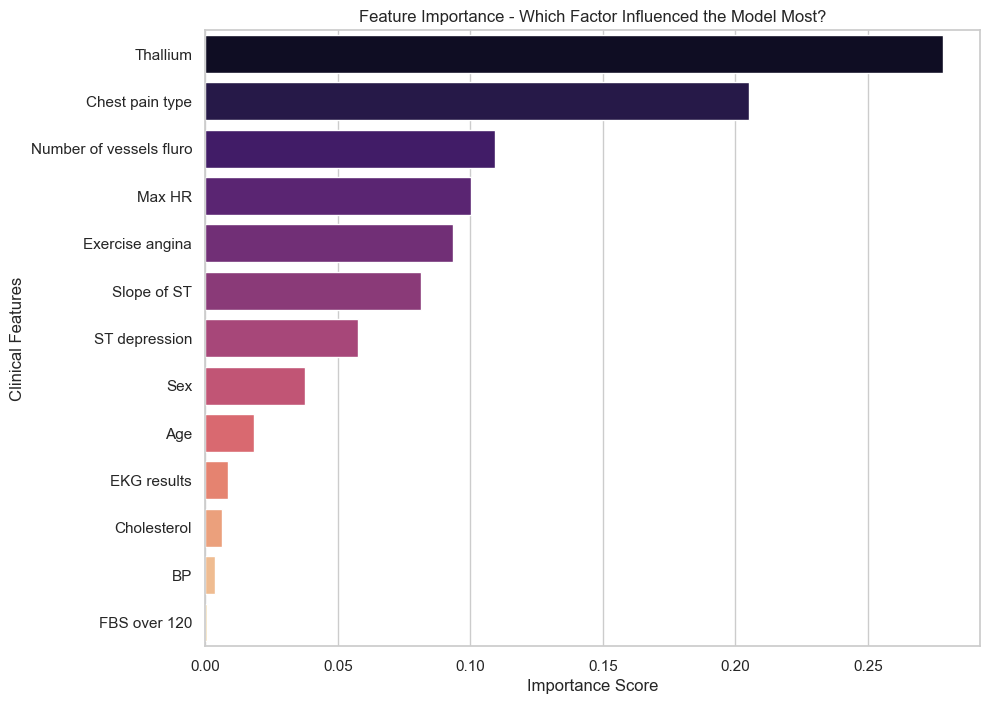

In [ ]:
# 1. Get feature importance from the Random Forest model
# Note: We use .feature_importances_ instead of .coef_
importances = rf_model.feature_importances_

# 2. Create a DataFrame for better organization
feature_data = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_data = feature_data.sort_values(by='Importance', ascending=False)

# 3. Print the scores
for index, row in feature_data.iterrows():
    print(f"Feature: {row['Feature']}, Score: {row['Importance']:.5f}")

# 4. Generate a horizontal bar plot for feature importance
# 'magma' palette is used for a professional and high-contrast visual
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature',hue='Feature', data=feature_data, palette='magma')

# 5. Add descriptive titles and labels for professional reporting
plt.title('Feature Importance - Which Factor Influenced the Model Most?')
plt.xlabel('Importance Score')
plt.ylabel('Clinical Features')
plt.show()

## saving the model

In [ ]:
## save the model
import joblib

# 1. Train the model with stricter constraints to reduce file size
# Setting max_depth=10 and n_estimators=50 will significantly shrink the file.
rf_model_small = RandomForestClassifier(
    n_estimators=50,       # Reduced the number of trees to 50
    max_depth=10,          # Restricted the depth of each tree (Pruning)
    min_samples_split=20,  # Increases the data needed to split a branch (Simplifies trees)
    n_jobs=-1,             # Use all available CPU cores for faster training
    random_state=42        # Ensures consistent results across runs
)

# Fit the model to the training data
rf_model_small.fit(X_train, y_train)

# 2. Save the model using high-level compression (Level 9)
# The 'compress=9' parameter ensures the smallest possible file size.
joblib.dump(rf_model_small, 'model.pkl', compress=9)

print("Model saved with high compression!")

Model saved with high compression!
